# Project 6: Chemical Similarity Search

In this project, we will perform chemical similarity search using RDKit. Chemical similarity is a core concept in cheminformatics, used to find molecules structurally similar to a query molecule (e.g., a known drug) from a database.

## Objectives
1. Calculate Morgan fingerprints for a dataset of molecules.
2. Compute Tanimoto similarity between a query molecule and a database.
3. Identify and visualize the most similar molecules.

In [ ]:
%%capture
! pip install rdkit pandas matplotlib seaborn

## 1. Import Required Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import DataStructs
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

# Set seaborn style for better plots
sns.set_theme(style='whitegrid')

## 2. Load the Dataset
For this project, we will use a small sample dataset of SMILES strings representing well-known NSAIDs (Non-Steroidal Anti-Inflammatory Drugs).

In [11]:
# load dataset 
import pandas as pd

dataset_path = r"C:\Users\rasel\jvai projects\Agents\AI-Engineer-for-Life-Sciences-Libraries\Cheminformatics\RDKit\dataset\molecules_100.csv"

df = pd.read_csv(dataset_path)

df.head()

,Name,SMILES
0,Water,O
1,Methane,C
2,Ethane,CC
3,Propane,CCC
4,Butane,CCCC


## 3. Convert SMILES to RDKit Molecules
Let's add a new column containing the RDKit Mol objects and visualize a few of them.

In [20]:
from IPython.display import display

df["Molecule"] = df["SMILES"].apply(Chem.MolFromSmiles)

display(df.head())

,Name,SMILES,Molecule,Fingerprint,Similarity
0,Water,O,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
1,Methane,C,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
2,Ethane,CC,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
3,Propane,CCC,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
4,Butane,CCCC,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0


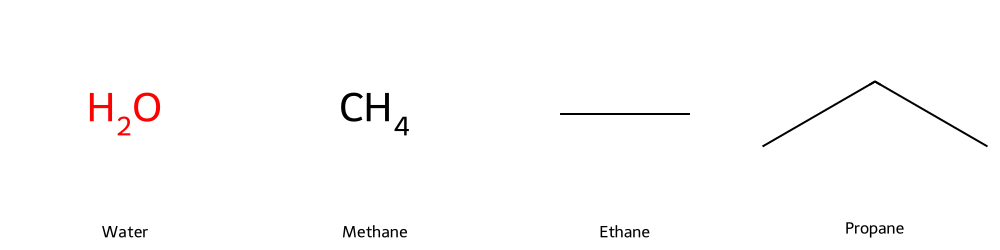

In [19]:
# Visualize the first 4 molecules
Draw.MolsToGridImage(df['Molecule'][:4], molsPerRow=4, subImgSize=(250, 250), legends=df['Name'][:4].tolist())

## 4. Define the Query Molecule
We'll use **Salicylic Acid** (the active metabolite of Aspirin) as our query molecule to search for structurally similar compounds in our dataset.

Query Molecule: Salicylic Acid


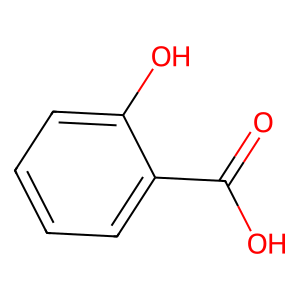

In [13]:
query_name = 'Salicylic Acid'
query_smiles = 'c1ccc(c(c1)C(=O)O)O'
query_mol = Chem.MolFromSmiles(query_smiles)

print(f"Query Molecule: {query_name}")
Draw.MolToImage(query_mol)

## 5. Calculate Morgan Fingerprints
Morgan fingerprints (circular fingerprints) represent the molecular structure as a bit vector. We will calculate these for both the query molecule and our dataset.

In [14]:
# Function to generate Morgan Fingerprint
def get_morgan_fingerprint(mol, radius=2, nBits=2048):
    if mol is not None:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    return None

# Calculate fingerprint for the query molecule
query_fp = get_morgan_fingerprint(query_mol)

# Calculate fingerprints for the database molecules
df['Fingerprint'] = df['Molecule'].apply(get_morgan_fingerprint)
df.head()

[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerator
[19:45:28] DEPRECATION WARNING: please use MorganGenerat

,Name,SMILES,Molecule,Fingerprint
0,Water,O,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,Methane,C,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Ethane,CC,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Propane,CCC,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Butane,CCCC,<rdkit.Chem.rdchem.Mol object at 0x00000191D61...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [21]:
# Fingerprint Analysis

fp = df["Fingerprint"].iloc[0]


print("1. Fingerprint (Binary Bit String)")
print("-" * 60)
print(fp.ToBitString())

print("\n" + "-" * 60)
print("2. Fingerprint as Python List")
print("-" * 60)
print(list(fp))

print("\n" + "-" * 60)
print("3. Fingerprint Length")
print("-" * 60)
print(len(fp))

print("\n" + "-" * 60)
print("4. Number of ON (1) Bits")
print("-" * 60)
print(fp.GetNumOnBits())

print("\n" + "-" * 60)
print("5. DataFrame Columns")
print("-" * 60)
print(df.columns)

1. Fingerprint (Binary Bit String)
------------------------------------------------------------
0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

## 6. Calculate Tanimoto Similarity
Tanimoto similarity is the most common metric for comparing fingerprints in cheminformatics. It ranges from 0 (no bits in common) to 1 (identical bit vectors).

In [15]:
# Calculate Tanimoto similarity for each molecule against the query
df['Similarity'] = df['Fingerprint'].apply(lambda x: DataStructs.TanimotoSimilarity(query_fp, x) if x is not None else 0.0)

# Sort the dataframe by similarity in descending order
df_sorted = df.sort_values(by='Similarity', ascending=False).reset_index(drop=True)
df_sorted[['Name', 'SMILES', 'Similarity']]

,Name,SMILES,Similarity
0,Benzoic Acid,C1=CC=C(C=C1)C(=O)O,0.454545
1,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,0.448276
2,Phenol,Oc1ccccc1,0.380952
3,Methyl Benzoate,COC(=O)c1ccccc1,0.321429
4,Ethyl Benzoate,CCOC(=O)c1ccccc1,0.290323
...,...,...,...
95,Cyclopropane,C1CC1,0.000000
96,Cyclopentane,C1CCCC1,0.000000
97,Dimethylamine,CN(C)C,0.000000
98,Trimethylamine,CN(C)C,0.000000


## 7. Visualize the Results
### Top Similar Molecules
Let's visualize the query molecule alongside the top 3 most similar molecules found in our database.

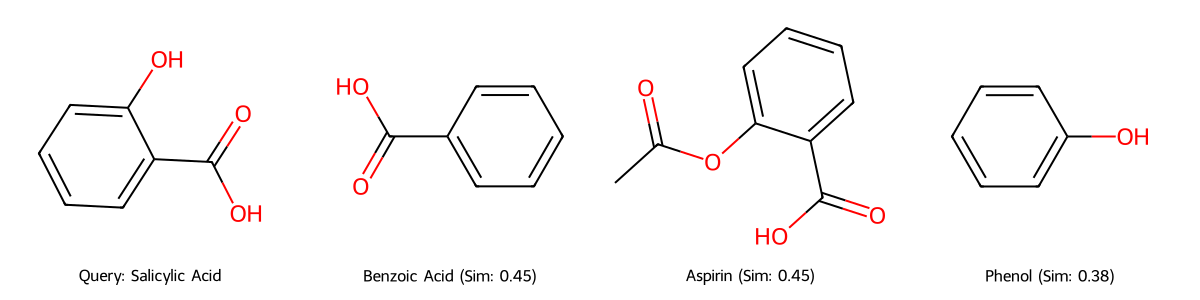

In [16]:
top_n = 3
top_mols = [query_mol] + df_sorted['Molecule'][:top_n].tolist()
top_names = [f"Query: {query_name}"] + [f"{row['Name']} (Sim: {row['Similarity']:.2f})" for _, row in df_sorted[:top_n].iterrows()]

Draw.MolsToGridImage(top_mols, molsPerRow=4, subImgSize=(300, 300), legends=top_names)

## Top 10 Similarity

In [23]:
# Ranking Molecules by Similarity

ranking_df = (
    df[["Name", "SMILES", "Similarity"]]
    .sort_values(by="Similarity", ascending=False)
    .reset_index(drop=True)
)

ranking_df["Rank"] = ranking_df.index + 1

ranking_df = ranking_df[
    ["Rank", "Name", "SMILES", "Similarity"]
]

ranking_df

,Rank,Name,SMILES,Similarity
0,1,Benzoic Acid,C1=CC=C(C=C1)C(=O)O,0.454545
1,2,Aspirin,CC(=O)OC1=CC=CC=C1C(=O)O,0.448276
2,3,Phenol,Oc1ccccc1,0.380952
3,4,Methyl Benzoate,COC(=O)c1ccccc1,0.321429
4,5,Ethyl Benzoate,CCOC(=O)c1ccccc1,0.290323
...,...,...,...,...
95,96,Cyclopropane,C1CC1,0.000000
96,97,Cyclopentane,C1CCCC1,0.000000
97,98,Dimethylamine,CN(C)C,0.000000
98,99,Trimethylamine,CN(C)C,0.000000


In [24]:
# Top 10 Most Similar Molecules
top10 = (
    ranking_df[ranking_df["Name"] != query_name]
    .head(10)
)


print(f"Top 10 Molecules Similar to {query_name}")
print("="*70)

print(top10.to_string(index=False))

Top 10 Molecules Similar to Salicylic Acid
 Rank            Name                         SMILES  Similarity
    1    Benzoic Acid            C1=CC=C(C=C1)C(=O)O    0.454545
    2         Aspirin       CC(=O)OC1=CC=CC=C1C(=O)O    0.448276
    3          Phenol                      Oc1ccccc1    0.380952
    4 Methyl Benzoate                COC(=O)c1ccccc1    0.321429
    5  Ethyl Benzoate               CCOC(=O)c1ccccc1    0.290323
    6       Lidocaine CCN(CC)C(=O)C1=CC=CC=C1N(CC)CC    0.285714
    7  Benzyl Alcohol                     OCc1ccccc1    0.280000
    8         Toluene                      Cc1ccccc1    0.260870
    9         Aniline                      Nc1ccccc1    0.260870
   10     Naphthalene                 c1cccc2ccccc12    0.238095


### Similarity Distribution
Let's plot a histogram of the similarity scores to see how similar the database molecules are to our query overall.

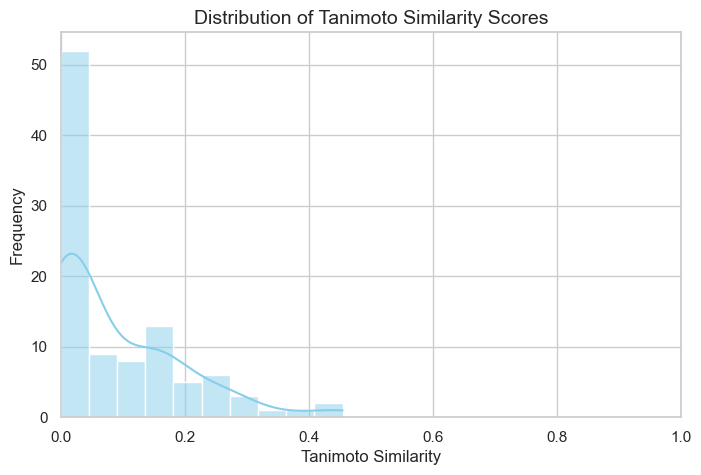

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sorted['Similarity'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Tanimoto Similarity Scores', fontsize=14)
plt.xlabel('Tanimoto Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 1)
plt.show()

## Conclusion
In this project, we successfully implemented a chemical similarity search workflow using RDKit. We loaded a dataset of molecules, generated Morgan fingerprints, calculated Tanimoto similarity scores against a query molecule, and visualized the most structurally similar compounds. This is a fundamental technique in early-stage drug discovery and virtual screening.